# XGBoost

In [1]:
# !python -m pip install seaborn

IMPORTS


In [2]:
import pandas as pd
import numpy as np  # ← add this
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder


In [3]:
df = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

Displaying Data 

In [4]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,Y
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,8.23
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,6.09
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,7.65
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,6.60
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,6.90


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      6000 non-null   str    
 1   X2      4994 non-null   float64
 2   X3      6000 non-null   str    
 3   X4      6000 non-null   float64
 4   X5      6000 non-null   str    
 5   X6      6000 non-null   float64
 6   X7      6000 non-null   str    
 7   X8      6000 non-null   int64  
 8   X9      4289 non-null   str    
 9   X10     6000 non-null   str    
 10  X11     6000 non-null   str    
 11  Y       6000 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 562.6 KB


In [6]:
df.describe(include='all')

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,Y
count,6000,4994.000000,6000,6000.000000,6000,6000.000000,6000,6000.000000,4289,6000,6000,6000.000000
unique,1553,NaN,5,NaN,16,NaN,10,NaN,3,3,4,NaN
top,FDP28,NaN,Low Fat,NaN,Fruits and Vegetables,NaN,OUT045,NaN,Medium,Tier 3,Supermarket Type1,NaN
freq,8,NaN,3595,NaN,875,NaN,677,NaN,1935,2358,3967,NaN
mean,NaN,12.956536,NaN,0.066333,NaN,141.228200,NaN,1997.840333,NaN,NaN,NaN,7.303403
std,NaN,4.658851,NaN,0.051492,NaN,62.540569,NaN,8.334412,NaN,NaN,NaN,1.014361
min,NaN,4.555000,NaN,0.000000,NaN,31.290000,NaN,1985.000000,NaN,NaN,NaN,3.510000
25%,NaN,8.895000,NaN,0.027030,NaN,94.037650,NaN,1987.000000,NaN,NaN,NaN,6.750000
50%,NaN,12.800000,NaN,0.054620,NaN,143.197000,NaN,1999.000000,NaN,NaN,NaN,7.500000
75%,NaN,17.100000,NaN,0.095154,NaN,186.522050,NaN,2004.000000,NaN,NaN,NaN,8.040000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.nunique()

X1     1553
X2      410
X3        5
X4     5577
X5       16
X6     4634
X7       10
X8        9
X9        3
X10       3
X11       4
Y       508
dtype: int64

In [9]:
item_fat_content = df['X3'].unique()
print(f"unique values in X3 : {item_fat_content} \n")
item_type = df['X5'].unique()
print(f"unique values in X5 : {item_type} \n")
outlet_identifier = df['X6'].unique()
print(f"unique values in X6 : {outlet_identifier} \n")
outlet_establishment_year = df['X8'].unique()
print(f"unique values in X8 : {outlet_establishment_year} \n")
outlet_size = df['X9'].unique()
print(f"unique values in X9 : {outlet_size} \n")
outlet_location_tier = df['X10'].unique()
print(f"unique values in X10 : {outlet_location_tier} \n")
outlet_type = df['X11'].unique()
print(f"unique values in X11 : {outlet_type} \n")

unique values in X3 : <StringArray>
['Low Fat', 'Regular', 'low fat', 'LF', 'reg']
Length: 5, dtype: str 

unique values in X5 : <StringArray>
[                'Dairy',           'Soft Drinks',                  'Meat',
 'Fruits and Vegetables',             'Household',          'Baking Goods',
           'Snack Foods',          'Frozen Foods',             'Breakfast',
    'Health and Hygiene',           'Hard Drinks',                'Canned',
                'Breads',         'Starchy Foods',                'Others',
               'Seafood']
Length: 16, dtype: str 

unique values in X6 : [249.8092  48.2692 141.618  ...  58.6246  60.4536 195.8452] 

unique values in X8 : [1999 2009 1998 1987 1985 2002 2007 1997 2004] 

unique values in X9 : <StringArray>
['Medium', nan, 'High', 'Small']
Length: 4, dtype: str 

unique values in X10 : <StringArray>
['Tier 1', 'Tier 3', 'Tier 2']
Length: 3, dtype: str 

unique values in X11 : <StringArray>
['Supermarket Type1', 'Supermarket Type2', 'Groce

In [10]:
x = df["X2"].mean()

df.fillna({"X2": x}, inplace=True)
# df.fillna({"outlet_Size": "Medium"}, inplace=True)
df['X9'] = df['X9'].fillna('Medium')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      6000 non-null   str    
 1   X2      6000 non-null   float64
 2   X3      6000 non-null   str    
 3   X4      6000 non-null   float64
 4   X5      6000 non-null   str    
 5   X6      6000 non-null   float64
 6   X7      6000 non-null   str    
 7   X8      6000 non-null   int64  
 8   X9      6000 non-null   str    
 9   X10     6000 non-null   str    
 10  X11     6000 non-null   str    
 11  Y       6000 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 562.6 KB


In [12]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,Y
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,8.23
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,6.09
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,7.65
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,6.60
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,6.90


Preprocessing

Low fat and regular handling

In [13]:
# for x in df.index:
#   if df.loc[x, "item_Fat_Content"] =="low fat" or df.loc[x, "item_Fat_Content"] =="LF":
#     df.loc[x, "item_Fat_Content"] = "Low Fat"
#   elif df.loc[x, "item_Fat_Content"] =="reg":
#     df.loc[x, "item_Fat_Content"] = "Regular"
df['X3'] = df['X3'].replace({'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'})

In [14]:
x3 = df['X3'].unique() 
print(f"unique values in X3 : {x3} \n")

unique values in X3 : <StringArray>
['Low Fat', 'Regular']
Length: 2, dtype: str 



age and mean in X4 and X6 handling


In [15]:
# Convert Establishment Year → Outlet Age
df['outlet_Age'] = 2026 - df['X8']

# Fix Item Visibility zeros
df['X4'] = df['X4'].replace(0, df[df['X4'] > 0]['X4'].mean())

# ← SAVE these before X4 gets dropped later
train_vis_mean    = df['X4'].mean()
train_weight_mean = df['X2'].mean()

In [16]:
df['log_X6'] = np.log1p(df['X6'])  
#df['X4_100'] = df['X4'] * 100           # log MRP
df['log_X4']       = np.log1p(df['X4'])               # log visibility
# df['vis_x_age']     = df['X4'] * df['outlet_Age']

In [17]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,Y,outlet_Age,log_X6,log_X4
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,8.23,27,5.524692,0.015920
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,6.09,17,3.897299,0.019095
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,7.65,27,4.960170,0.016621
3,FDX07,19.20,Regular,0.070567,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,6.60,28,5.210005,0.068189
4,NCD19,8.93,Low Fat,0.070567,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,6.90,39,4.004810,0.068189


Encoding X9 and X10

In [18]:
df['X9'] = df['X9'].map({'Small': 1, 'Medium': 2, 'High': 3})

In [19]:
tier_map = {'Tier 1': 3, 'Tier 2': 2, 'Tier 3': 1}
df['X10'] = df['X10'].map(tier_map)

# Result: 'Tier 1' = 3 (highest), 'Tier 2' = 2, 'Tier 3' = 1 (lowest)
print(df['X10'].value_counts())

X10
1    2358
2    1992
3    1650
Name: count, dtype: int64


In [20]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,Y,outlet_Age,log_X6,log_X4
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,2,3,Supermarket Type1,8.23,27,5.524692,0.015920
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,2,1,Supermarket Type2,6.09,17,3.897299,0.019095
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,2,3,Supermarket Type1,7.65,27,4.960170,0.016621
3,FDX07,19.20,Regular,0.070567,Fruits and Vegetables,182.0950,OUT010,1998,2,1,Grocery Store,6.60,28,5.210005,0.068189
4,NCD19,8.93,Low Fat,0.070567,Household,53.8614,OUT013,1987,3,1,Supermarket Type1,6.90,39,4.004810,0.068189


In [21]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
cat_cols = ['X3', 'X5', 'X11', 'X7']  # ← removed 'item_Identifier' , 'X9'

# Training
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

# Test
# for col in cat_cols:
#     le = encoders[col]
#     mapping = {cat: idx for idx, cat in enumerate(le.classes_)}
#     test[col] = test[col].astype(str).map(mapping).fillna(-1).astype(int)

In [22]:
x = df.drop(columns=['Y', 'X1', 'X8', 'X6', 'X7', 'X4'])
y = df['Y']
x = x.fillna(x.mean())

In [23]:
df.head(15)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,Y,outlet_Age,log_X6,log_X4
0,FDA15,9.300000,0,0.016047,4,249.8092,9,1999,2,3,1,8.23,27,5.524692,0.015920
1,DRC01,5.920000,1,0.019278,14,48.2692,3,2009,2,1,2,6.09,17,3.897299,0.019095
2,FDN15,17.500000,0,0.016760,10,141.6180,9,1999,2,3,1,7.65,27,4.960170,0.016621
3,FDX07,19.200000,1,0.070567,6,182.0950,0,1998,2,1,0,6.60,28,5.210005,0.068189
4,NCD19,8.930000,0,0.070567,9,53.8614,1,1987,3,1,1,6.90,39,4.004810,0.068189
5,FDP36,10.395000,1,0.070567,0,51.4008,3,2009,2,1,2,6.32,17,3.958922,0.068189
6,FDO10,13.650000,1,0.012741,13,57.6588,1,1987,3,1,1,5.84,39,4.071738,0.012661
7,FDP10,12.956536,0,0.127470,13,107.7622,5,1985,2,1,3,8.30,41,4.689164,0.119976
8,FDH17,16.200000,1,0.016687,5,96.9726,7,2002,2,2,1,6.98,24,4.584688,0.016549
9,FDU28,19.200000,1,0.094450,5,187.8214,2,2007,2,2,1,8.46,19,5.240802,0.090252


MSE AND RMSE AND HEATMAP


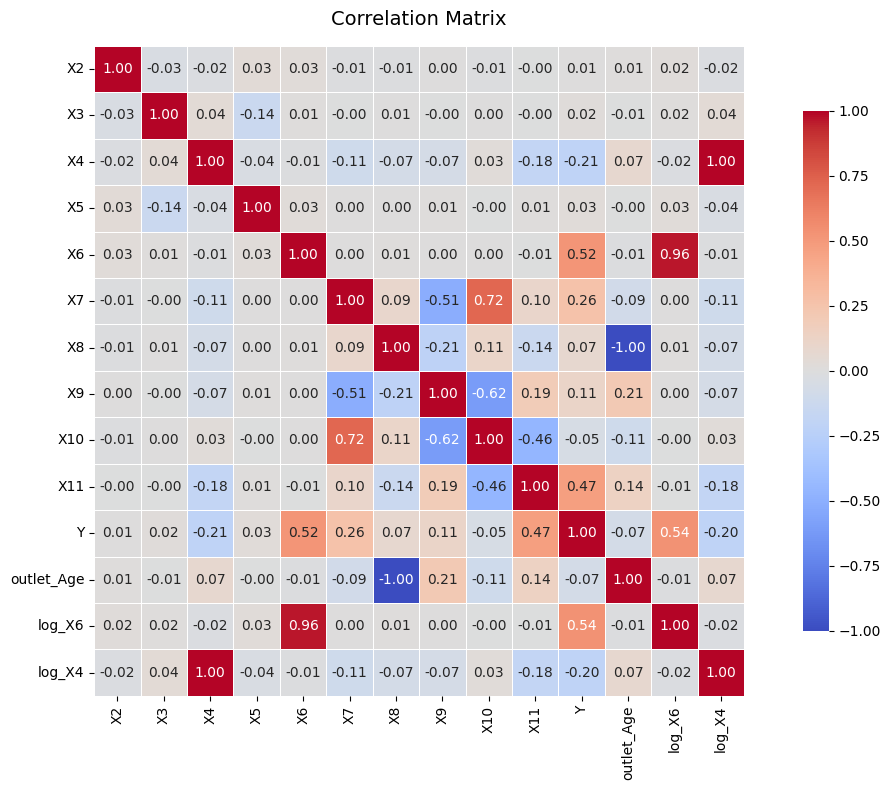

In [24]:
# sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
# plt.show()
# # Calculate MSE
# mse = mean_squared_error(y_test, y_pred)                                  #! heatmap

# print("Mean Squared Error:", mse) 
plt.figure(figsize=(12, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

XGBoost

In [25]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.3408658085569444


In [26]:
df.head(15)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,Y,outlet_Age,log_X6,log_X4
0,FDA15,9.300000,0,0.016047,4,249.8092,9,1999,2,3,1,8.23,27,5.524692,0.015920
1,DRC01,5.920000,1,0.019278,14,48.2692,3,2009,2,1,2,6.09,17,3.897299,0.019095
2,FDN15,17.500000,0,0.016760,10,141.6180,9,1999,2,3,1,7.65,27,4.960170,0.016621
3,FDX07,19.200000,1,0.070567,6,182.0950,0,1998,2,1,0,6.60,28,5.210005,0.068189
4,NCD19,8.930000,0,0.070567,9,53.8614,1,1987,3,1,1,6.90,39,4.004810,0.068189
5,FDP36,10.395000,1,0.070567,0,51.4008,3,2009,2,1,2,6.32,17,3.958922,0.068189
6,FDO10,13.650000,1,0.012741,13,57.6588,1,1987,3,1,1,5.84,39,4.071738,0.012661
7,FDP10,12.956536,0,0.127470,13,107.7622,5,1985,2,1,3,8.30,41,4.689164,0.119976
8,FDH17,16.200000,1,0.016687,5,96.9726,7,2002,2,2,1,6.98,24,4.584688,0.016549
9,FDU28,19.200000,1,0.094450,5,187.8214,2,2007,2,2,1,8.46,19,5.240802,0.090252


In [27]:
# model = LinearRegression()
# model.fit(X_train, y_train)
print('Model trained on', X_train.shape[1], 'features')

Model trained on 9 features


In [28]:
y_pred = model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2   = model.score(X_test, y_test)

print(f'Mean Squared Error  (MSE)  : {mse:.6f}')
print(f'Root Mean Sq. Error (RMSE) : {rmse:.6f}')
print(f'R² Score                   : {r2:.4f}')
# print(test.columns.tolist())
# print(x.columns.tolist())

Mean Squared Error  (MSE)  : 0.340866
Root Mean Sq. Error (RMSE) : 0.583837
R² Score                   : 0.6825


Preprocessing test file 


In [29]:
test['X3'] = test['X3'].replace({'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'})
test['X2'] = test['X2'].fillna(train_weight_mean)   # ← saved train mean
test['X9'] = test['X9'].fillna('Medium')
test['X4'] = test['X4'].replace(0, train_vis_mean) 
#test['X4_100'] = test['X4'] * 100 # ← saved train mean
test['log_X4'] = np.log1p(test['X4'])
test['outlet_Age'] = 2026 - test['X8']
test['log_X6'] = np.log1p(test['X6'])
test['X9']  = test['X9'].map({'Small': 1, 'Medium': 2, 'High': 3})
test['X10'] = test['X10'].map({'Tier 1': 3, 'Tier 2': 2, 'Tier 3': 1})

# Encode categoricals using saved encoders from training
for col in cat_cols:
    le = encoders[col]
    mapping = {cat: idx for idx, cat in enumerate(le.classes_)}
    test[col] = test[col].astype(str).map(mapping).fillna(-1).astype(int)

In [30]:
drop_cols = ['X1', 'X7', 'X8', 'X6','X4']
X_test_submit = test.drop(columns=drop_cols)
X_test_submit = X_test_submit.fillna(0)
X_test_submit = X_test_submit.reindex(columns=x.columns, fill_value=0)

print(f'Features: {X_test_submit.shape[1]}')
print(f'NaN count: {X_test_submit.isna().sum().sum()}')
preds = model.predict(X_test_submit)
print(f'Prediction range: {preds.min():.2f} - {preds.max():.2f}')

# print("NaN in X_test_submit:", X_test_submit.isna().sum().sum())
# print("Shape train x:", x.shape)
# print("Shape test:", X_test_submit.shape)
# print("Any columns all zeros:", (X_test_submit == 0).all().sum())

Features: 9
NaN count: 0
Prediction range: 3.61 - 8.92


In [31]:
test.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,log_X4,outlet_Age,log_X6
0,FDO37,12.956536,0,0.021273,2,229.1326,5,1985,2,1,3,0.021050,41,5.438656
1,FDV13,17.350000,1,0.027588,3,86.1856,1,1987,3,1,1,0.027214,39,4.468039
2,FDF52,9.300000,0,0.111782,5,182.3292,0,1998,2,1,0,0.105964,28,5.211283
3,FDY11,6.710000,1,0.029606,0,65.4142,9,1999,2,3,1,0.029177,27,4.195911
4,FDL20,17.100000,0,0.129141,6,109.4886,2,2007,2,2,1,0.121457,19,4.704912


add data to submission to sample_submission.csv

In [32]:
submission = pd.read_csv('sample_submission.csv')
submission['Y'] = preds
submission.to_csv('sample_submission.csv', index=False)
print(submission.head())

   row_id         Y
0       0  8.547554
1       1  6.776913
2       2  6.081985
3       3  6.800865
4       4  7.109171


Kaggle score : 0.408